# Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks
### Open Project 2026 — Society of Business

**Datasets:**
- **ACN-Data**: 16,304 EV charging sessions from Caltech (Apr–Dec 2018)
- **ST-EVCDP (UrbanEV)**: 247 stations × 8,640 timestamps (5-min intervals, Jun–Jul 2022, Shenzhen)

**Pipeline:**
1. Data Loading & Preprocessing
2. Feature Engineering & Unified Data Pool
3. Exploratory Data Analysis (EDA)
4. Demand Prediction Agent
5. Tariff Pricing Agent
6. Monitoring & Learning Agent
7. Evaluation Summary

## 0. Setup & Libraries

In [30]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Clustering for network analysis
from sklearn.cluster import KMeans

# Network analysis
import networkx as nx

# Set style
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data Loading & Preprocessing
### 1A. ACN-Data (Caltech Charging Sessions)

In [31]:
# ---------- Load ACN ----------
acn_raw = pd.read_excel('C:/Users/pragy/Downloads/Analytics_Summer_projects_2026/EV_dynamic_pricing_socbiz/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx')
print(f'ACN raw shape: {acn_raw.shape}')
print(acn_raw.dtypes[['connectionTime','disconnectTime','doneChargingTime','kWhDelivered','stationID','siteID']])

ACN raw shape: (16304, 27)
connectionTime          str
disconnectTime          str
doneChargingTime        str
kWhDelivered        float64
stationID               str
siteID              float64
dtype: object


In [32]:
# ---------- Parse ACN timestamps ----------
def parse_acn_dt(series):
    return pd.to_datetime(series, format='%a, %d %b %Y %H:%M:%S GMT', utc=True, errors='coerce')

acn = acn_raw.copy()
acn['connectionTime']   = parse_acn_dt(acn['connectionTime'])
acn['disconnectTime']   = parse_acn_dt(acn['disconnectTime'])
acn['doneChargingTime'] = parse_acn_dt(acn['doneChargingTime'])

# Convert to US/Pacific for local analysis
for col in ['connectionTime', 'disconnectTime', 'doneChargingTime']:
    acn[col] = acn[col].dt.tz_convert('America/Los_Angeles')

# Drop rows missing critical fields
print(f'Missing kWhDelivered before drop: {acn["kWhDelivered"].isna().sum()}')
acn = acn.dropna(subset=['connectionTime', 'kWhDelivered'])
print(f'ACN after dropping nulls: {acn.shape}')

# Derived time fields
acn['session_duration_hr']  = (acn['disconnectTime'] - acn['connectionTime']).dt.total_seconds() / 3600
acn['charging_duration_hr'] = (acn['doneChargingTime'] - acn['connectionTime']).dt.total_seconds() / 3600
acn['idle_duration_hr']     = acn['session_duration_hr'] - acn['charging_duration_hr']

# Clip implausible values
acn = acn[(acn['session_duration_hr'] > 0) & (acn['session_duration_hr'] < 48)]
acn = acn[(acn['kWhDelivered'] > 0) & (acn['kWhDelivered'] < 100)]

# Temporal features
acn['date']        = acn['connectionTime'].dt.date
acn['hour']        = acn['connectionTime'].dt.hour
acn['dayofweek']   = acn['connectionTime'].dt.dayofweek   # 0=Mon
acn['week']        = acn['connectionTime'].dt.isocalendar().week.astype(int)
acn['is_weekend']  = (acn['dayofweek'] >= 5).astype(int)
acn['month']       = acn['connectionTime'].dt.month
acn['avg_power_kW'] = acn['kWhDelivered'] / acn['charging_duration_hr'].clip(lower=0.1)

print(acn[['session_duration_hr','charging_duration_hr','idle_duration_hr','kWhDelivered','avg_power_kW']].describe().round(2))

Missing kWhDelivered before drop: 1305
ACN after dropping nulls: (14999, 27)
       session_duration_hr  charging_duration_hr  idle_duration_hr  \
count             14947.00              14939.00          14939.00   
mean                  5.68                  3.20              2.48   
std                   4.59                  2.86              3.76   
min                   0.09                 -0.69             -0.02   
25%                   2.02                  1.27              0.00   
50%                   4.74                  2.24              0.73   
75%                   8.71                  4.24              4.14   
max                  47.59                 45.46             46.11   

       kWhDelivered  avg_power_kW  
count      14947.00      14939.00  
mean           9.00          3.57  
std            7.05          2.50  
min            0.50          0.04  
25%            4.00          2.03  
50%            7.44          3.10  
75%           13.20          5.42  
max 

In [33]:
# ---------- Missing value summary for ACN ----------
missing = acn.isnull().sum()
missing_pct = (missing / len(acn) * 100).round(2)
mv_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
mv_df = mv_df[mv_df['Missing'] > 0].sort_values('Pct', ascending=False)
print('ACN Missing Values:')
print(mv_df.head(15))

# Imputation assumptions (documented)
# kWhRequested: proxy user intent — fill with median per station
acn['kWhRequested'] = acn.groupby('stationID')['kWhRequested'].transform(
    lambda x: x.fillna(x.median())
)
# milesRequested: fill with 0 (not provided)
acn['milesRequested'] = acn['milesRequested'].fillna(0)
# minutesAvailable: fill with median session duration in minutes
acn['minutesAvailable'] = acn['minutesAvailable'].fillna(acn['session_duration_hr'].median() * 60)
print('\nImputation complete.')

ACN Missing Values:
                    Missing     Pct
_meta                 14947  100.00
min_kWh               14947  100.00
start                 14947  100.00
_items                14947  100.00
userInputs            14947  100.00
end                   14947  100.00
site                  14946   99.99
minutesAvailable      12722   85.11
userID.1              12722   85.11
requestedDeparture    12722   85.11
paymentRequired       12722   85.11
modifiedAt            12722   85.11
kWhRequested          12722   85.11
milesRequested        12722   85.11
WhPerMile             12722   85.11

Imputation complete.


### 1B. ST-EVCDP (UrbanEV) Dataset — Shenzhen

In [34]:
DIR_PATH = 'C:/Users/pragy/Downloads/Analytics_Summer_projects_2026/EV_dynamic_pricing_socbiz/UrbanEV_ SZ_districts/'

# ---------- Load ST-EVCDP ----------
time_df     = pd.read_csv(DIR_PATH + 'time.csv')
duration_df = pd.read_csv(DIR_PATH + 'duration.csv')
volume_df   = pd.read_csv(DIR_PATH + 'volume.csv')
adj_df      = pd.read_csv(DIR_PATH + 'adj.csv')
distance_df = pd.read_csv(DIR_PATH + 'distance.csv')
info_df     = pd.read_csv(DIR_PATH + 'information.csv')
occupancy_df= pd.read_csv(DIR_PATH + 'occupancy.csv')
price_df    = pd.read_csv(DIR_PATH + 'price.csv')
stations_df = pd.read_csv(DIR_PATH + 'stations.csv')

print('time shape:', time_df.shape)
print('duration shape:', duration_df.shape)
print('volume shape:', volume_df.shape)
print('occupancy shape:', occupancy_df.shape)
print('price shape:', price_df.shape)
print('info shape:', info_df.shape)
print('stations shape:', stations_df.shape)

time shape: (8640, 6)
duration shape: (8640, 248)
volume shape: (8640, 248)
occupancy shape: (8640, 248)
price shape: (8640, 248)
info shape: (247, 10)
stations shape: (1706, 6)


In [35]:
# ---------- Build datetime index for ST-EVCDP ----------
time_df['datetime'] = pd.to_datetime(
    time_df[['year','month','day','hour','minute','second']]
)
datetime_index = time_df['datetime']

print(f'Date range: {datetime_index.iloc[0]} → {datetime_index.iloc[-1]}')
print(f'Interval: {(datetime_index.iloc[1] - datetime_index.iloc[0]).total_seconds()/60:.0f} minutes')
print(f'Total time steps: {len(datetime_index)}')
print(f'Number of stations in ST-EVCDP: {len(duration_df.columns) - 1}')

Date range: 2022-06-19 00:00:00 → 2022-07-18 23:55:00
Interval: 5 minutes
Total time steps: 8640
Number of stations in ST-EVCDP: 247


In [36]:
# ---------- Build tidy long-format ST-EVCDP panel ----------
station_ids = [c for c in duration_df.columns if c != 'timestamp']

def wide_to_long(df, value_name, datetime_index):
    """Convert wide matrix (timestamp × station) to long format."""
    sid_cols = [c for c in df.columns if c != 'timestamp']
    df2 = df[sid_cols].copy()
    df2.index = datetime_index.values
    long = df2.stack().reset_index()
    long.columns = ['datetime', 'station_id', value_name]
    long['station_id'] = long['station_id'].astype(str)
    return long

dur_long  = wide_to_long(duration_df,  'avg_duration_hr',  datetime_index)
vol_long  = wide_to_long(volume_df,    'session_volume',   datetime_index)
occ_long  = wide_to_long(occupancy_df, 'occupancy_count',  datetime_index)
price_long= wide_to_long(price_df,     'price_yuan_kwh',   datetime_index)

# Merge into unified urban panel
urban = dur_long.copy()
for df2, col in [(vol_long,'session_volume'), (occ_long,'occupancy_count'), (price_long,'price_yuan_kwh')]:
    urban = urban.merge(df2[['datetime','station_id',col]], on=['datetime','station_id'], how='left')

# Merge station metadata
info_df['station_id'] = info_df['grid'].astype(str)
urban = urban.merge(info_df[['station_id','count','fast_count','slow_count','area','lon','la','CBD','dynamic_pricing']],
                    on='station_id', how='left')

# Temporal features
urban['hour']       = pd.to_datetime(urban['datetime']).dt.hour
urban['dayofweek']  = pd.to_datetime(urban['datetime']).dt.dayofweek
urban['is_weekend'] = (urban['dayofweek'] >= 5).astype(int)
urban['date']       = pd.to_datetime(urban['datetime']).dt.date

print(f'Urban panel shape: {urban.shape}')
print(urban.dtypes)
print(urban.head(3))

Urban panel shape: (2134080, 18)
datetime           datetime64[us]
station_id                    str
avg_duration_hr           float64
session_volume            float64
occupancy_count             int64
price_yuan_kwh            float64
count                       int64
fast_count                  int64
slow_count                  int64
area                      float64
lon                       float64
la                        float64
CBD                         int64
dynamic_pricing             int64
hour                        int32
dayofweek                   int32
is_weekend                  int32
date                       object
dtype: object
    datetime station_id  avg_duration_hr  session_volume  occupancy_count  \
0 2022-06-19        102         0.490000        2.858333               12   
1 2022-06-19        105         0.871111        5.907222               16   
2 2022-06-19        107         0.980000        6.478889               24   

   price_yuan_kwh  count  fast_c

In [37]:
# ---------- Missing values in urban panel ----------
mv_urban = urban.isnull().sum()
print('Urban panel nulls:')
print(mv_urban[mv_urban > 0])

# Fill with station-level median (forward-fill for time series continuity)
for col in ['avg_duration_hr','session_volume','occupancy_count','price_yuan_kwh']:
    urban[col] = urban.groupby('station_id')[col].transform(
        lambda x: x.fillna(x.median())
    )

print('Urban panel nulls after imputation:')
print(urban.isnull().sum()[urban.isnull().sum() > 0])

Urban panel nulls:
Series([], dtype: int64)
Urban panel nulls after imputation:
Series([], dtype: int64)


---
## 2. Feature Engineering
### 2A. ACN Features

In [38]:
# ---------- ACN: Session-level feature engineering ----------

# Charger Utilization Rate = charging time / total session time
acn['utilization_rate'] = (acn['charging_duration_hr'] / acn['session_duration_hr']).clip(0, 1)

# Revenue per Session (baseline ₹15/kWh fixed tariff)
BASE_TARIFF_INR = 15.0   # ₹ per kWh
acn['revenue_inr'] = acn['kWhDelivered'] * BASE_TARIFF_INR

# Queue Length Proxy: concurrent sessions at same station in same hour
acn_hourly = acn.groupby(['stationID', 'date', 'hour']).agg(
    sessions_in_slot=('sessionID','count'),
    kwh_in_slot=('kWhDelivered','sum'),
    avg_util=('utilization_rate','mean')
).reset_index()
acn_hourly['queue_proxy'] = (acn_hourly['sessions_in_slot'] - 1).clip(lower=0)

# Time-of-day category
def time_bucket(h):
    if 0 <= h < 6: return 'off_peak_night'
    elif 6 <= h < 9: return 'morning_ramp'
    elif 9 <= h < 17: return 'daytime'
    elif 17 <= h < 21: return 'evening_peak'
    else: return 'off_peak_late'

acn['time_bucket'] = acn['hour'].map(time_bucket)
acn_hourly['time_bucket'] = acn_hourly['hour'].map(time_bucket)

# Cyclic encoding of hour
for df in [acn, acn_hourly]:
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
    df['dayofweek'] = df['date'].dt.dayofweek
    df['dow_sin']  = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']  = np.cos(2 * np.pi * df['dayofweek'] / 7)

print('ACN feature summary:')
print(acn[['utilization_rate','revenue_inr','avg_power_kW','session_duration_hr']].describe().round(2))

ACN feature summary:
       utilization_rate  revenue_inr  avg_power_kW  session_duration_hr
count          14939.00     14947.00      14939.00             14947.00
mean               0.69       134.94          3.57                 5.68
std                0.32       105.80          2.50                 4.59
min                0.00         7.52          0.04                 0.09
25%                0.39        60.02          2.03                 2.02
50%                0.82       111.52          3.10                 4.74
75%                1.00       198.06          5.42                 8.71
max                1.00      1040.60        149.67                47.59


### 2B. ST-EVCDP Features

In [39]:
# ---------- Urban: station-level feature engineering ----------

# Charger utilization rate = occupied piles / total piles
urban['utilization_rate'] = (urban['occupancy_count'] / urban['count'].clip(lower=1)).clip(0, 1)

# Revenue per slot (volume × duration × price)
urban['revenue_slot'] = urban['session_volume'] * urban['avg_duration_hr'] * urban['price_yuan_kwh']

# Congestion flag: utilization > 0.80
urban['is_congested'] = (urban['utilization_rate'] > 0.80).astype(int)

# Off-peak flag: utilization < 0.30
urban['is_off_peak'] = (urban['utilization_rate'] < 0.30).astype(int)

# Time-of-day bucket
urban['time_bucket'] = urban['hour'].map(time_bucket)

# Cyclic encoding
urban['hour_sin'] = np.sin(2 * np.pi * urban['hour'] / 24)
urban['hour_cos'] = np.cos(2 * np.pi * urban['hour'] / 24)
urban['dow_sin']  = np.sin(2 * np.pi * urban['dayofweek'] / 7)
urban['dow_cos']  = np.cos(2 * np.pi * urban['dayofweek'] / 7)

# Lag features per station (1 step = 5 min, 12 steps = 1 hour)
urban = urban.sort_values(['station_id','datetime'])
for lag in [1, 12, 24*12]:   # 5-min, 1-hour, 1-day lags
    urban[f'vol_lag_{lag}'] = urban.groupby('station_id')['session_volume'].shift(lag)
    urban[f'util_lag_{lag}'] = urban.groupby('station_id')['utilization_rate'].shift(lag)

# Rolling mean (1-hour window = 12 steps)
urban['vol_roll12'] = urban.groupby('station_id')['session_volume'].transform(
    lambda x: x.rolling(12, min_periods=1).mean()
)
urban['util_roll12'] = urban.groupby('station_id')['utilization_rate'].transform(
    lambda x: x.rolling(12, min_periods=1).mean()
)

# Fast charger ratio
urban['fast_ratio'] = urban['fast_count'] / urban['count'].clip(lower=1)

print('Urban engineered features:')
print(urban[['utilization_rate','is_congested','is_off_peak','revenue_slot','vol_roll12']].describe().round(3))

Urban engineered features:
       utilization_rate  is_congested  is_off_peak  revenue_slot   vol_roll12
count       2134080.000   2134080.000  2134080.000   2134080.000  2134080.000
mean              0.280         0.010        0.609       111.970       36.676
std               0.176         0.101        0.488       491.415      101.055
min               0.000         0.000        0.000         0.000        0.000
25%               0.152         0.000        0.000         0.778        2.333
50%               0.250         0.000        1.000         6.000        7.000
75%               0.378         0.000        1.000        42.201       23.505
max               1.000         1.000        1.000     11793.716     1457.339


In [40]:
# ---------- Save processed data ----------
acn.to_csv('acn_processed.csv', index=False)
urban.to_csv('urban_processed.csv', index=False)
acn_hourly.to_csv('acn_hourly.csv', index=False)
print('Processed files saved.')

Processed files saved.


---
## 3. Exploratory Data Analysis (EDA)
### 3A. ACN — Session-Level Demand Patterns

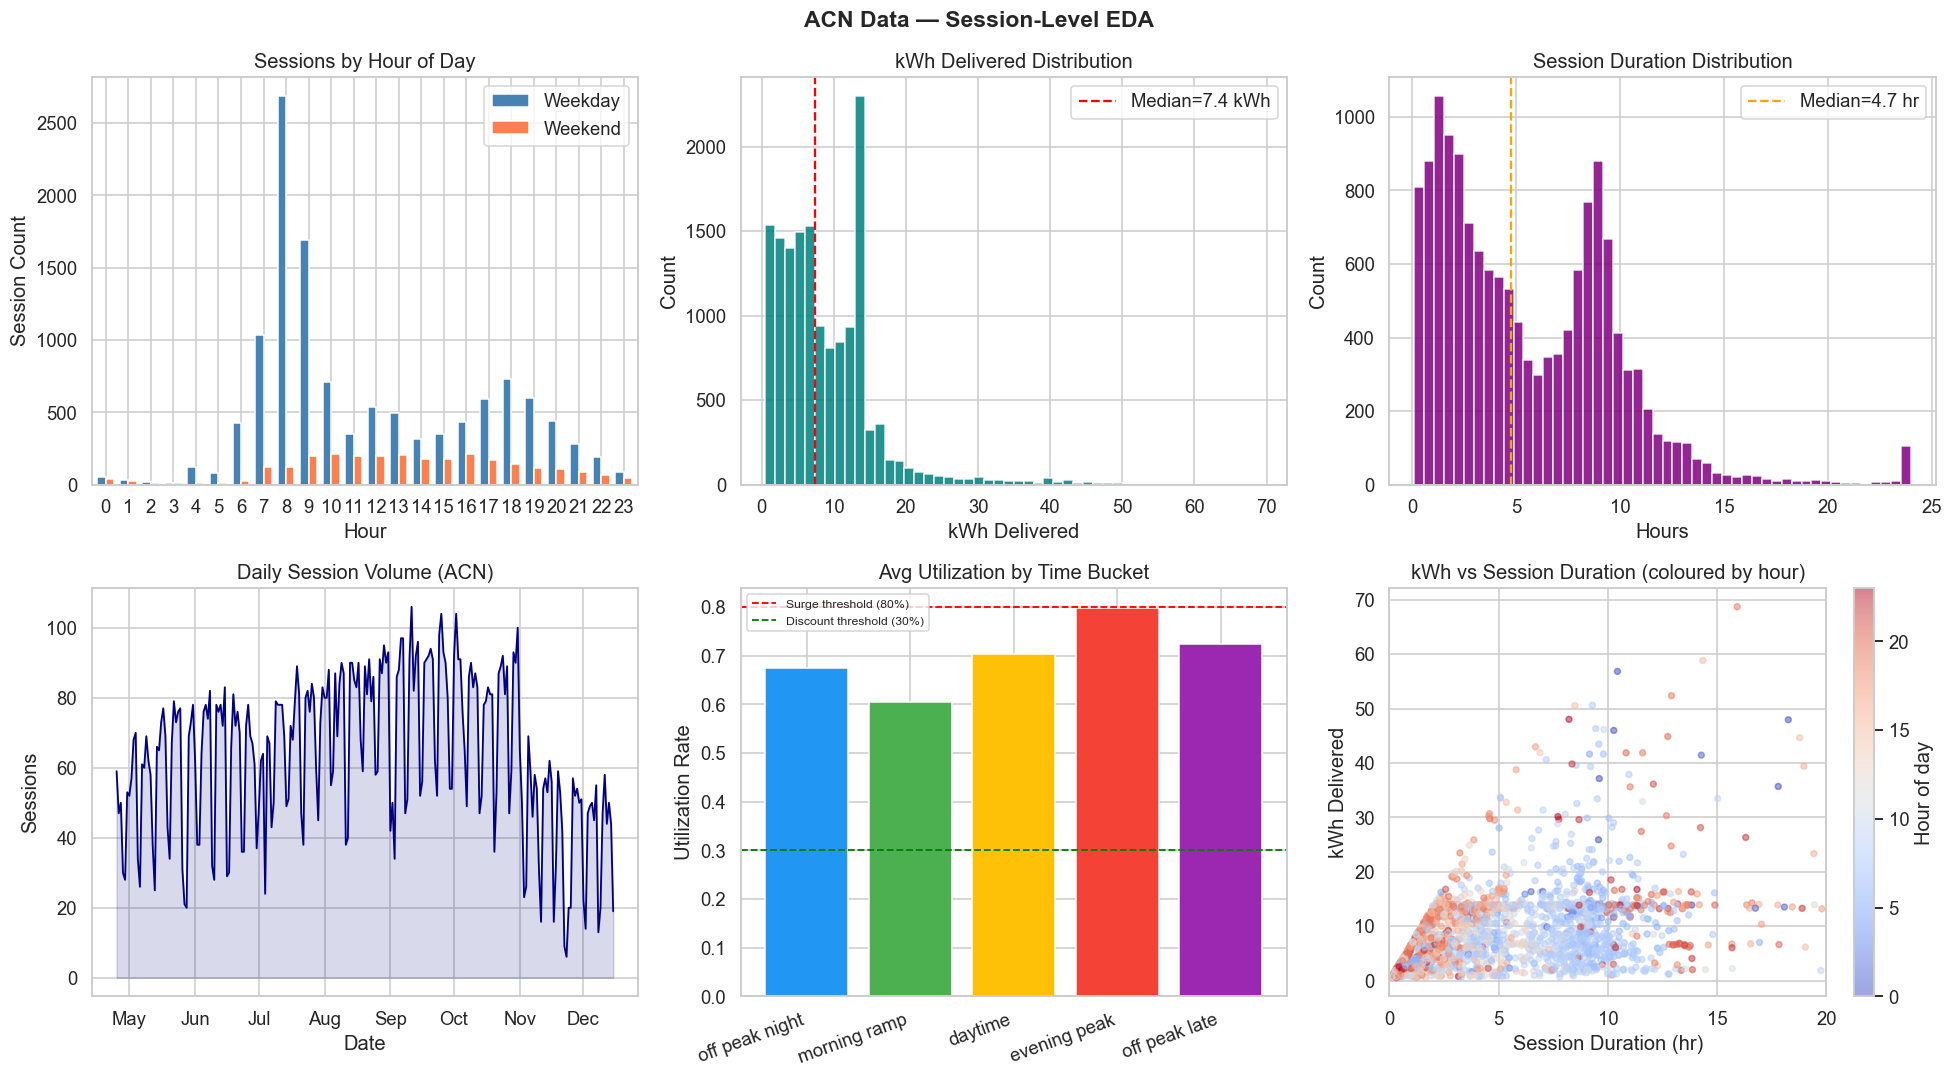

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ACN Data — Session-Level EDA', fontsize=15, fontweight='bold')

# 1. Sessions per hour of day
ax = axes[0, 0]
hourly_counts = acn.groupby(['hour','is_weekend']).size().unstack(fill_value=0)
hourly_counts.plot(kind='bar', ax=ax, color=['steelblue','coral'], width=0.75)
ax.set_title('Sessions by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Session Count')
ax.legend(['Weekday','Weekend'])
ax.tick_params(axis='x', rotation=0)

# 2. kWh distribution
ax = axes[0, 1]
ax.hist(acn['kWhDelivered'], bins=50, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(acn['kWhDelivered'].median(), color='red', linestyle='--', label=f'Median={acn["kWhDelivered"].median():.1f} kWh')
ax.set_title('kWh Delivered Distribution')
ax.set_xlabel('kWh Delivered')
ax.set_ylabel('Count')
ax.legend()

# 3. Session duration distribution
ax = axes[0, 2]
ax.hist(acn['session_duration_hr'].clip(0,24), bins=50, color='purple', edgecolor='white', alpha=0.85)
ax.axvline(acn['session_duration_hr'].median(), color='orange', linestyle='--',
           label=f'Median={acn["session_duration_hr"].median():.1f} hr')
ax.set_title('Session Duration Distribution')
ax.set_xlabel('Hours')
ax.set_ylabel('Count')
ax.legend()

# 4. Daily session volume trend
ax = axes[1, 0]
daily = acn.groupby('date').size().reset_index(name='sessions')
daily['date'] = pd.to_datetime(daily['date'])
ax.plot(daily['date'], daily['sessions'], color='navy', linewidth=1.2)
ax.fill_between(daily['date'], daily['sessions'], alpha=0.15, color='navy')
ax.set_title('Daily Session Volume (ACN)')
ax.set_xlabel('Date')
ax.set_ylabel('Sessions')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# 5. Utilization by time bucket
ax = axes[1, 1]
bucket_order = ['off_peak_night','morning_ramp','daytime','evening_peak','off_peak_late']
util_bucket = acn.groupby('time_bucket')['utilization_rate'].mean().reindex(bucket_order)
colors = ['#2196F3','#4CAF50','#FFC107','#F44336','#9C27B0']
ax.bar(range(len(util_bucket)), util_bucket.values, color=colors)
ax.set_xticks(range(len(util_bucket)))
ax.set_xticklabels([b.replace('_',' ') for b in bucket_order], rotation=20, ha='right')
ax.axhline(0.80, color='red', linestyle='--', linewidth=1.2, label='Surge threshold (80%)')
ax.axhline(0.30, color='green', linestyle='--', linewidth=1.2, label='Discount threshold (30%)')
ax.set_title('Avg Utilization by Time Bucket')
ax.set_ylabel('Utilization Rate')
ax.legend(fontsize=8)

# 6. kWh vs session duration scatter
ax = axes[1, 2]
sample = acn.sample(min(2000, len(acn)), random_state=SEED)
sc = ax.scatter(sample['session_duration_hr'], sample['kWhDelivered'],
                c=sample['hour'], cmap='coolwarm', alpha=0.5, s=15)
plt.colorbar(sc, ax=ax, label='Hour of day')
ax.set_title('kWh vs Session Duration (coloured by hour)')
ax.set_xlabel('Session Duration (hr)')
ax.set_ylabel('kWh Delivered')
ax.set_xlim(0, 20)

plt.tight_layout()
plt.savefig('eda_acn.png')
plt.show()

### 3B. Urban (ST-EVCDP) — Temporal & Spatial Demand Patterns

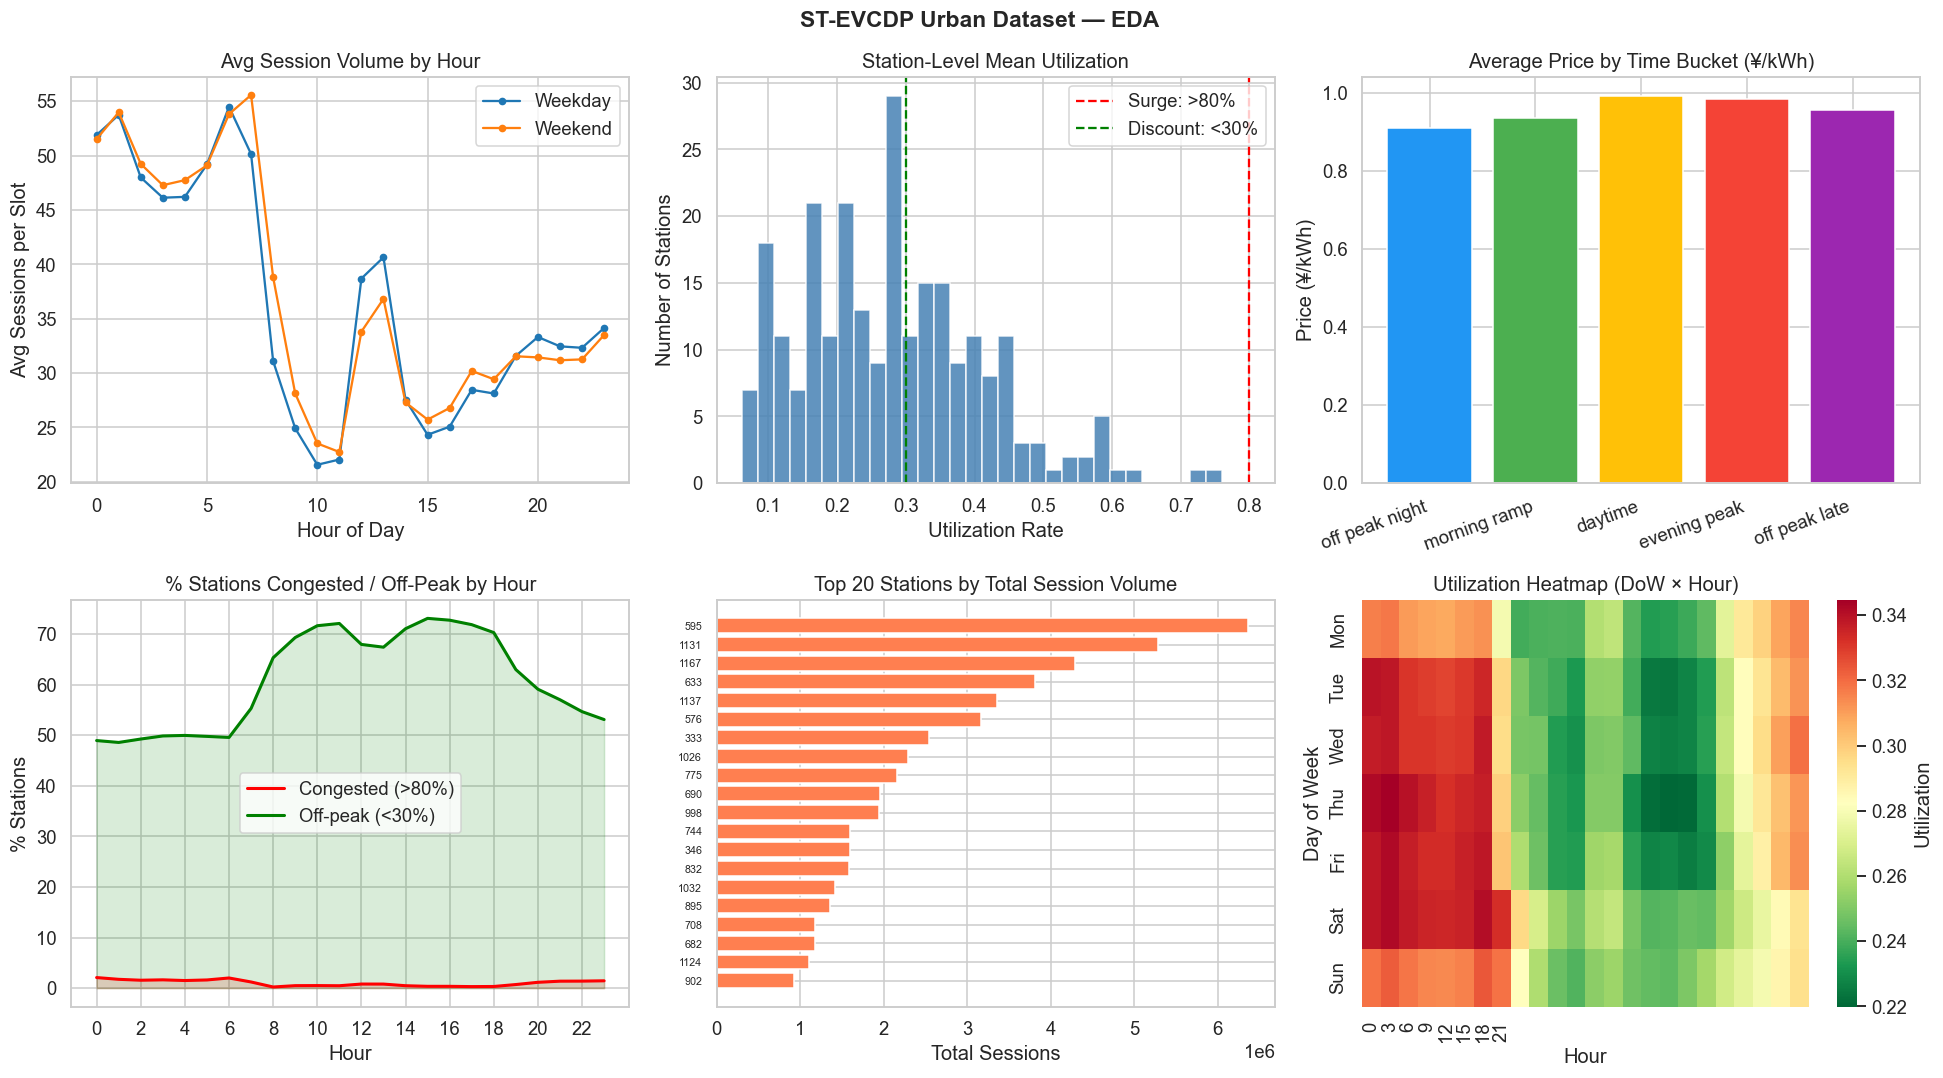

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ST-EVCDP Urban Dataset — EDA', fontsize=15, fontweight='bold')

# 1. Average session volume by hour
ax = axes[0, 0]
vol_hour = urban.groupby(['hour','is_weekend'])['session_volume'].mean().unstack(fill_value=0)
vol_hour.plot(kind='line', ax=ax, marker='o', markersize=4)
ax.set_title('Avg Session Volume by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Sessions per Slot')
ax.legend(['Weekday','Weekend'])

# 2. Utilization rate distribution across stations
ax = axes[0, 1]
util_by_station = urban.groupby('station_id')['utilization_rate'].mean().sort_values()
ax.hist(util_by_station, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.80, color='red', linestyle='--', label='Surge: >80%')
ax.axvline(0.30, color='green', linestyle='--', label='Discount: <30%')
ax.set_title('Station-Level Mean Utilization')
ax.set_xlabel('Utilization Rate')
ax.set_ylabel('Number of Stations')
ax.legend()

# 3. Price variation by time bucket
ax = axes[0, 2]
price_bucket = urban.groupby('time_bucket')['price_yuan_kwh'].mean().reindex(bucket_order)
ax.bar(range(len(price_bucket)), price_bucket.values, color=colors)
ax.set_xticks(range(len(price_bucket)))
ax.set_xticklabels([b.replace('_',' ') for b in bucket_order], rotation=20, ha='right')
ax.set_title('Average Price by Time Bucket (¥/kWh)')
ax.set_ylabel('Price (¥/kWh)')

# 4. Congestion proportion by hour
ax = axes[1, 0]
cong_hour = urban.groupby('hour')['is_congested'].mean() * 100
offpk_hour = urban.groupby('hour')['is_off_peak'].mean() * 100
ax.plot(cong_hour.index,  cong_hour.values,  color='red',   label='Congested (>80%)', linewidth=2)
ax.plot(offpk_hour.index, offpk_hour.values, color='green', label='Off-peak (<30%)',   linewidth=2)
ax.fill_between(cong_hour.index, cong_hour.values, alpha=0.15, color='red')
ax.fill_between(offpk_hour.index, offpk_hour.values, alpha=0.15, color='green')
ax.set_title('% Stations Congested / Off-Peak by Hour')
ax.set_xlabel('Hour')
ax.set_ylabel('% Stations')
ax.legend()
ax.set_xticks(range(0,24,2))

# 5. Top-20 busiest stations
ax = axes[1, 1]
top20 = urban.groupby('station_id')['session_volume'].sum().nlargest(20)
ax.barh(range(20), top20.values[::-1], color='coral')
ax.set_yticks(range(20))
ax.set_yticklabels(top20.index[::-1], fontsize=7)
ax.set_title('Top 20 Stations by Total Session Volume')
ax.set_xlabel('Total Sessions')

# 6. Weekday vs Weekend utilization heatmap
ax = axes[1, 2]
pivot = urban.groupby(['dayofweek','hour'])['utilization_rate'].mean().unstack()
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', linewidths=0,
            xticklabels=range(0,24,3), yticklabels=days, cbar_kws={'label':'Utilization'})
ax.set_title('Utilization Heatmap (DoW × Hour)')
ax.set_xlabel('Hour')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('eda_urban.png')
plt.show()

### 3C. Network / Spatial Analysis

In [43]:
# ---------- Build station graph from adjacency matrix ----------
adj = adj_df.set_index('node_id')
adj.columns = adj.columns.astype(str)
adj.index   = adj.index.astype(str)

G = nx.from_pandas_adjacency(adj)

# Attach station-level attributes
station_util = urban.groupby('station_id')['utilization_rate'].mean().to_dict()
station_vol  = urban.groupby('station_id')['session_volume'].sum().to_dict()
for node in G.nodes():
    G.nodes[node]['utilization'] = station_util.get(node, 0)
    G.nodes[node]['volume']      = station_vol.get(node, 0)

# Network metrics
degree_centrality = nx.degree_centrality(G)
betweenness       = nx.betweenness_centrality(G)

net_metrics = pd.DataFrame({
    'station_id': list(degree_centrality.keys()),
    'degree_centrality': list(degree_centrality.values()),
    'betweenness':       list(betweenness.values()),
    'utilization':       [station_util.get(k,0) for k in degree_centrality.keys()],
    'total_volume':      [station_vol.get(k,0)  for k in degree_centrality.keys()],
})
net_metrics.to_csv('network_metrics.csv', index=False)

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print('Top 10 stations by degree centrality:')
print(net_metrics.nlargest(10, 'degree_centrality')[['station_id','degree_centrality','utilization','total_volume']])

Network: 247 nodes, 750 edges
Top 10 stations by degree centrality:
    station_id  degree_centrality  utilization   total_volume
31         326           0.052846     0.333857   62925.798055
36         332           0.048780     0.322792  285091.898196
84         681           0.048780     0.218210    9695.608611
121        773           0.040650     0.324262  130286.096111
124        783           0.040650     0.086892   10462.120278
186       1062           0.040650     0.148701   97360.420001
239       1163           0.040650     0.091030    8204.338333
11         204           0.036585     0.121554   34466.333611
12         205           0.036585     0.083069   22042.193056
23         235           0.036585     0.340943   50747.003611


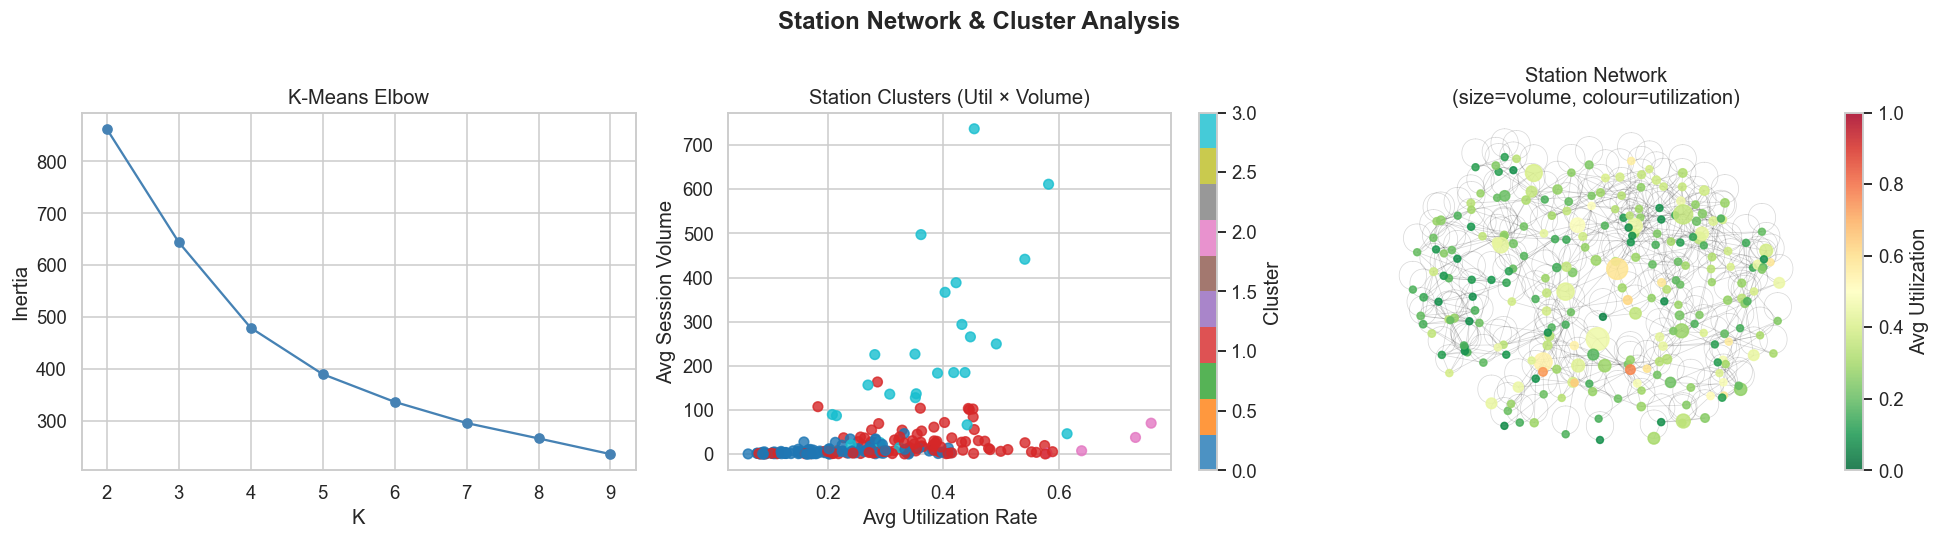


Cluster profile:
         avg_util  avg_vol  avg_price  pct_congested  fast_ratio
cluster                                                         
0           0.201    7.122      1.078          0.002       0.028
1           0.332   23.368      0.857          0.002       0.060
2           0.678   29.506      0.775          0.402       0.346
3           0.375  214.622      0.840          0.017       0.731


In [44]:
# ---------- Station cluster analysis via K-Means ----------
cluster_feats = urban.groupby('station_id').agg(
    avg_util=('utilization_rate','mean'),
    avg_vol=('session_volume','mean'),
    avg_price=('price_yuan_kwh','mean'),
    pct_congested=('is_congested','mean'),
    count=('count','first'),
    fast_ratio=('fast_ratio','first'),
    CBD=('CBD','first')
).dropna()

scaler = StandardScaler()
X_cl = scaler.fit_transform(cluster_feats[['avg_util','avg_vol','avg_price','pct_congested','fast_ratio']])

# Elbow method
inertias = [KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(X_cl).inertia_ for k in range(2,10)]

km = KMeans(n_clusters=4, random_state=SEED, n_init=10)
cluster_feats['cluster'] = km.fit_predict(X_cl)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Station Network & Cluster Analysis', fontweight='bold')

# Elbow
axes[0].plot(range(2,10), inertias, 'o-', color='steelblue')
axes[0].set_title('K-Means Elbow')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')

# Scatter: utilization vs volume, coloured by cluster
sc = axes[1].scatter(cluster_feats['avg_util'], cluster_feats['avg_vol'],
                     c=cluster_feats['cluster'], cmap='tab10', s=40, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label='Cluster')
axes[1].set_title('Station Clusters (Util × Volume)')
axes[1].set_xlabel('Avg Utilization Rate')
axes[1].set_ylabel('Avg Session Volume')

# Network visualisation (spring layout, sized by volume, coloured by utilization)
ax = axes[2]
pos = nx.spring_layout(G, seed=SEED, k=0.3)
node_utils = [G.nodes[n].get('utilization', 0) for n in G.nodes()]
node_vols  = [max(G.nodes[n].get('volume', 1), 1) for n in G.nodes()]
max_vol = max(node_vols)
node_sizes = [200 * v / max_vol + 20 for v in node_vols]
nc = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_utils,
                             cmap='RdYlGn_r', vmin=0, vmax=1, alpha=0.85)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5)
plt.colorbar(nc, ax=ax, label='Avg Utilization')
ax.set_title('Station Network\n(size=volume, colour=utilization)')
ax.axis('off')

plt.tight_layout()
plt.savefig('network_analysis.png')
plt.show()

print('\nCluster profile:')
print(cluster_feats.groupby('cluster')[['avg_util','avg_vol','avg_price','pct_congested','fast_ratio']].mean().round(3))

---
## 4. Demand Prediction Agent

Target: `utilization_rate` (next 5-min slot) at station level.
Model: Gradient Boosting Regressor with time-series cross-validation.

In [ ]:
# ---------- Prepare modelling dataset ----------
FEATURE_COLS = [
    'hour_sin','hour_cos','dow_sin','dow_cos','is_weekend',
    'vol_lag_1','vol_lag_12','vol_lag_288',
    'util_lag_1','util_lag_12','util_lag_288',
    'vol_roll12','util_roll12',
    'count','fast_ratio','CBD', 
    'session_volume','avg_duration_hr','price_yuan_kwh', 
    'utilization_rate'
]
TARGET = 'utilization_rate'

model_df = urban[FEATURE_COLS + [TARGET, 'datetime', 'station_id']].dropna()
model_df = model_df.sort_values('datetime').reset_index(drop=True)

print(f'Modelling dataset: {model_df.shape}')
print(f'Feature count: {len(FEATURE_COLS)}')
print(f'Target mean: {model_df[TARGET].mean():.3f}, std: {model_df[TARGET].std():.3f}')

Modelling dataset: (2062944, 22)
Feature count: 19
Target mean: 0.280, std: 0.176


In [49]:
# ---------- Train / Test split (last 20% as test — respects time order) ----------
split_idx = int(len(model_df) * 0.80)
train_df  = model_df.iloc[:split_idx]
test_df   = model_df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET].values

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (1650355, 19), Test: (412589, 19)


In [50]:
# ---------- Demand Prediction Agent: Gradient Boosting ----------
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, subsample=0.8,
    min_samples_leaf=20, random_state=SEED
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print('=== Demand Prediction Agent — Gradient Boosting ===')
print(f'RMSE : {rmse_gb:.4f}')
print(f'MAE  : {mae_gb:.4f}')
print(f'R²   : {r2_gb:.4f}')

=== Demand Prediction Agent — Gradient Boosting ===
RMSE : 0.0123
MAE  : 0.0048
R²   : 0.9951


In [51]:
# ---------- Benchmark: Random Forest ----------
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=10,
    min_samples_leaf=20, random_state=SEED, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Benchmark: Random Forest ===')
print(f'RMSE : {rmse_rf:.4f}')
print(f'MAE  : {mae_rf:.4f}')
print(f'R²   : {r2_rf:.4f}')

# Save metrics
demand_metrics = pd.DataFrame({
    'model': ['GradientBoosting','RandomForest'],
    'RMSE': [rmse_gb, rmse_rf],
    'MAE':  [mae_gb,  mae_rf],
    'R2':   [r2_gb,   r2_rf]
})
demand_metrics.to_csv('demand_prediction_metrics.csv', index=False)
print('\nMetrics saved.')

KeyboardInterrupt: 

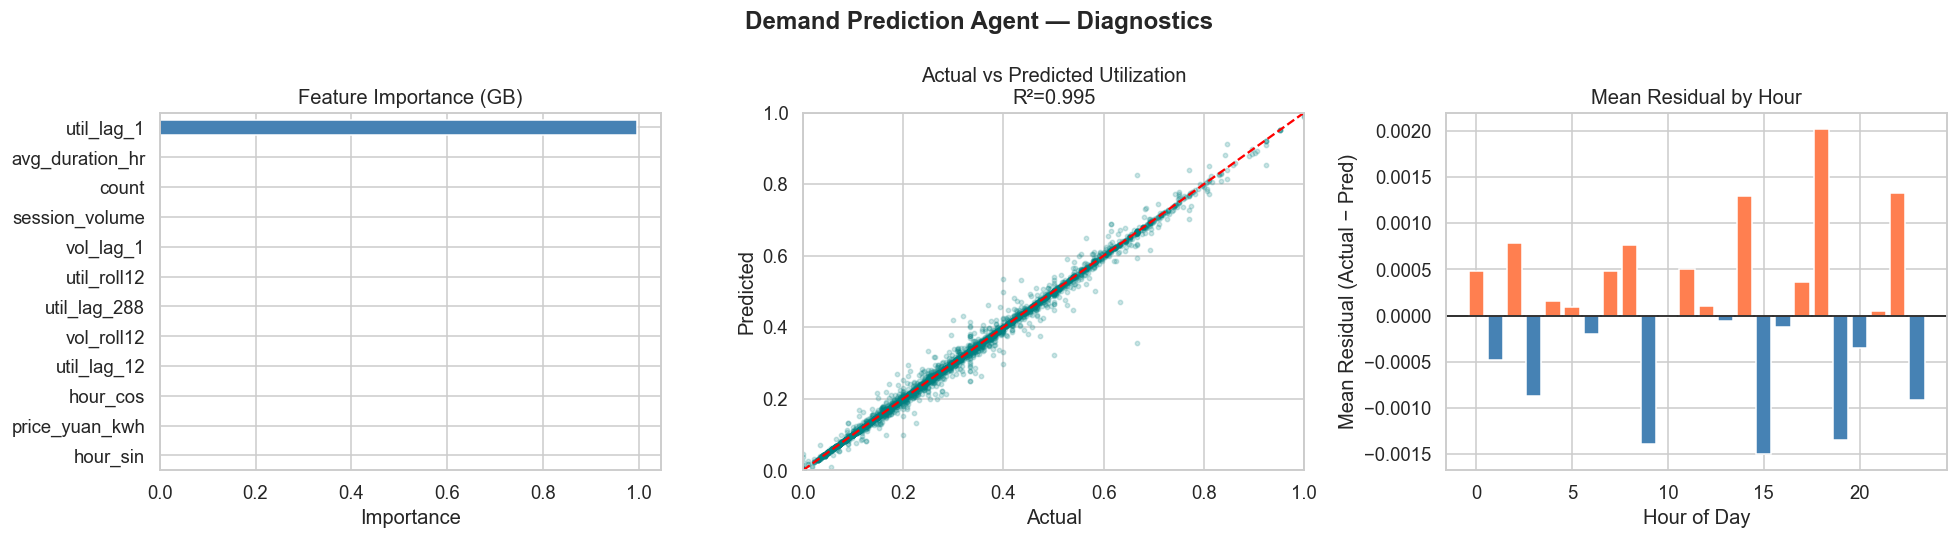

In [52]:
# ---------- Feature Importance + Residual Diagnostics ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Demand Prediction Agent — Diagnostics', fontweight='bold')

# Feature importance
ax = axes[0]
importances = pd.Series(gb_model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.tail(12).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (GB)')
ax.set_xlabel('Importance')

# Actual vs Predicted (sample)
ax = axes[1]
sample_n = min(5000, len(y_test))
idx = np.random.choice(len(y_test), sample_n, replace=False)
ax.scatter(y_test[idx], y_pred_gb[idx], alpha=0.2, s=8, color='teal')
lim = [0, 1]
ax.plot(lim, lim, 'r--', linewidth=1.5)
ax.set_title(f'Actual vs Predicted Utilization\nR²={r2_gb:.3f}')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_xlim(lim); ax.set_ylim(lim)

# Residuals by hour
ax = axes[2]
residuals = y_test - y_pred_gb
test_hours = test_df['datetime'].dt.hour.values
res_by_hour = pd.Series(residuals).groupby(test_hours).mean()
ax.bar(res_by_hour.index, res_by_hour.values, color=np.where(res_by_hour.values > 0,'coral','steelblue'))
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Mean Residual by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Residual (Actual − Pred)')

plt.tight_layout()
plt.savefig('demand_agent_diagnostics.png')
plt.show()

In [53]:
# ---------- Predict congestion probability (classification threshold) ----------
test_df = test_df.copy()
test_df['pred_util']         = y_pred_gb
test_df['congestion_prob']   = (y_pred_gb >= 0.70).astype(float)  # soft: within 10% of threshold
test_df['pred_congested']    = (y_pred_gb >= 0.80).astype(int)
test_df['pred_off_peak']     = (y_pred_gb < 0.30).astype(int)

from sklearn.metrics import classification_report
print('=== Congestion Classification Report ===')
print(classification_report(
    (y_test >= 0.80).astype(int),
    test_df['pred_congested'],
    target_names=['Not Congested','Congested']
))

=== Congestion Classification Report ===
               precision    recall  f1-score   support

Not Congested       1.00      1.00      1.00    408358
    Congested       0.97      0.94      0.95      4231

     accuracy                           1.00    412589
    macro avg       0.98      0.97      0.98    412589
 weighted avg       1.00      1.00      1.00    412589



---
## 5. Tariff Pricing Agent

Rule-based + regression pricing engine:
- Surge multiplier when predicted utilization > 80%
- Discount when predicted utilization < 30%
- Gradient Boosting price regression for intermediate states

In [54]:
# ---------- Tariff Agent: dynamic pricing logic ----------

BASE_PRICE_YUAN  = urban['price_yuan_kwh'].median()   # observed base (~1.0 ¥/kWh)
SURGE_MULT       = 1.30   # +30% surge
DISCOUNT_MULT    = 0.75   # −25% discount
SURGE_THRESHOLD  = 0.80
OFFPEAK_THRESHOLD= 0.30

def tariff_pricing_agent(pred_util, base_price=BASE_PRICE_YUAN):
    """
    Tariff Pricing Agent:
    - util > 0.80 → surge pricing
    - util < 0.30 → discount pricing
    - else → linear interpolation (shoulder zone)
    """
    prices = np.where(
        pred_util >= SURGE_THRESHOLD,
        base_price * SURGE_MULT,
        np.where(
            pred_util < OFFPEAK_THRESHOLD,
            base_price * DISCOUNT_MULT,
            base_price * (1 + 0.55 * (pred_util - OFFPEAK_THRESHOLD) / (SURGE_THRESHOLD - OFFPEAK_THRESHOLD))
        )
    )
    return prices

# Apply to test set
test_df['dynamic_tariff'] = tariff_pricing_agent(test_df['pred_util'].values)
test_df['static_tariff']  = BASE_PRICE_YUAN

# Revenue calculation (volume × avg_duration × tariff)
test_df['rev_dynamic'] = test_df['session_volume'] * test_df['avg_duration_hr'] * test_df['dynamic_tariff']
test_df['rev_static']  = test_df['session_volume'] * test_df['avg_duration_hr'] * test_df['static_tariff']

# Pricing efficiency
rev_dynamic_total = test_df['rev_dynamic'].sum()
rev_static_total  = test_df['rev_static'].sum()
revenue_gain_pct  = (rev_dynamic_total - rev_static_total) / rev_static_total * 100

print(f'Base price used: ¥{BASE_PRICE_YUAN:.3f}/kWh')
print(f'Total Revenue — Static:  ¥{rev_static_total:,.0f}')
print(f'Total Revenue — Dynamic: ¥{rev_dynamic_total:,.0f}')
print(f'Revenue Gain: {revenue_gain_pct:.2f}%')

Base price used: ¥0.984/kWh
Total Revenue — Static:  ¥65,552,620
Total Revenue — Dynamic: ¥78,897,223
Revenue Gain: 20.36%


In [55]:
# ---------- Charger Utilization Rate before & after ----------
# Demand elasticity proxy: if price rises, some sessions shift to off-peak
# Assume own-price elasticity of -0.3 (literature range -0.2 to -0.5)
ELASTICITY = -0.30

price_change_pct = (test_df['dynamic_tariff'] - test_df['static_tariff']) / test_df['static_tariff']
demand_change_pct = ELASTICITY * price_change_pct

test_df['adj_volume_dynamic'] = test_df['session_volume'] * (1 + demand_change_pct)
test_df['adj_util_dynamic']   = (test_df['adj_volume_dynamic'] / test_df['session_volume'].replace(0,np.nan) * test_df['utilization_rate']).clip(0,1)

# Off-peak uplift: increase in sessions during off-peak slots after discount
offpeak_mask = test_df['pred_off_peak'] == 1
offpeak_before = test_df.loc[offpeak_mask, 'session_volume'].sum()
offpeak_after  = test_df.loc[offpeak_mask, 'adj_volume_dynamic'].sum()
offpeak_uplift_pct = (offpeak_after - offpeak_before) / (offpeak_before + 1e-6) * 100

# Charger utilization before/after
util_before = test_df['utilization_rate'].mean()
util_after  = test_df['adj_util_dynamic'].mean()

print(f'Charger Utilization — Before: {util_before:.3f} | After: {util_after:.3f}')
print(f'Off-Peak Session Uplift: {offpeak_uplift_pct:.1f}%')

Charger Utilization — Before: 0.289 | After: 0.292
Off-Peak Session Uplift: 7.5%


KeyError: 'time_bucket'

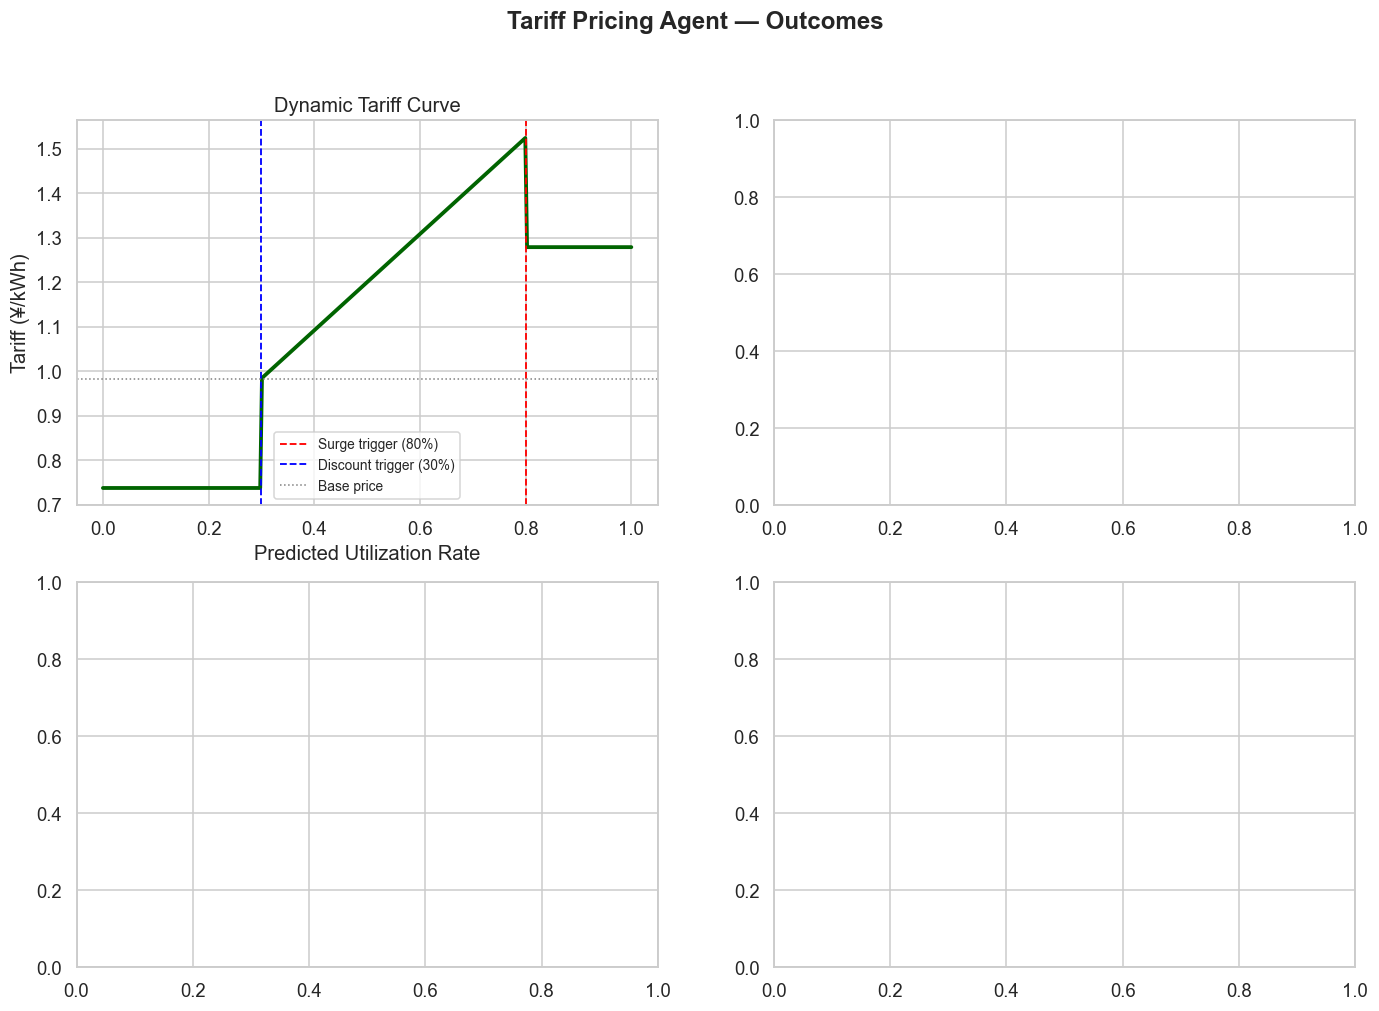

In [56]:
# ---------- Pricing visualisation ----------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Tariff Pricing Agent — Outcomes', fontweight='bold')

# 1. Price curve: utilization → tariff
ax = axes[0, 0]
util_range = np.linspace(0, 1, 300)
price_curve = tariff_pricing_agent(util_range)
ax.plot(util_range, price_curve, color='darkgreen', linewidth=2.5)
ax.axvline(SURGE_THRESHOLD,   color='red',   linestyle='--', linewidth=1.2, label='Surge trigger (80%)')
ax.axvline(OFFPEAK_THRESHOLD, color='blue',  linestyle='--', linewidth=1.2, label='Discount trigger (30%)')
ax.axhline(BASE_PRICE_YUAN,   color='gray',  linestyle=':', linewidth=1, label='Base price')
ax.set_title('Dynamic Tariff Curve')
ax.set_xlabel('Predicted Utilization Rate')
ax.set_ylabel('Tariff (¥/kWh)')
ax.legend(fontsize=9)

# 2. Revenue comparison by time bucket
ax = axes[0, 1]
rev_compare = test_df.groupby('time_bucket')[['rev_static','rev_dynamic']].sum().reindex(bucket_order)
x = np.arange(len(rev_compare))
width = 0.35
ax.bar(x - width/2, rev_compare['rev_static'],  width, label='Static',  color='steelblue', alpha=0.85)
ax.bar(x + width/2, rev_compare['rev_dynamic'], width, label='Dynamic', color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([b.replace('_',' ') for b in bucket_order], rotation=20, ha='right')
ax.set_title('Revenue: Static vs Dynamic by Time Bucket')
ax.set_ylabel('Revenue (¥)')
ax.legend()

# 3. Tariff distribution by congestion state
ax = axes[1, 0]
for state, label, col in [(1,'Congested','red'),(0,'Not Congested','steelblue')]:
    mask = test_df['pred_congested'] == state
    ax.hist(test_df.loc[mask, 'dynamic_tariff'], bins=30, alpha=0.6, label=label, color=col, density=True)
ax.set_title('Dynamic Tariff Distribution by State')
ax.set_xlabel('Tariff (¥/kWh)')
ax.set_ylabel('Density')
ax.legend()

# 4. Utilization shift: before vs after dynamic pricing
ax = axes[1, 1]
hour_util_before = test_df.groupby('hour')['utilization_rate'].mean()
hour_util_after  = test_df.groupby('hour')['adj_util_dynamic'].mean()
ax.plot(hour_util_before.index, hour_util_before.values, 'o-', color='steelblue', label='Before (static)', linewidth=2)
ax.plot(hour_util_after.index,  hour_util_after.values,  's--',color='coral',     label='After (dynamic)', linewidth=2)
ax.axhline(SURGE_THRESHOLD,   color='red',  linestyle=':',  linewidth=1)
ax.axhline(OFFPEAK_THRESHOLD, color='green',linestyle=':', linewidth=1)
ax.set_title('Hourly Utilization: Before vs After Dynamic Pricing')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Utilization Rate')
ax.legend()
ax.set_xticks(range(0,24,2))

plt.tight_layout()
plt.savefig('tariff_agent_outcomes.png')
plt.show()

In [57]:
# ---------- Tariff Pricing Agent metrics summary ----------
tariff_metrics = pd.DataFrame({
    'Metric': ['Revenue Gain (%)', 'Charger Util Before', 'Charger Util After',
               'Off-Peak Session Uplift (%)', 'Base Price (¥/kWh)',
               'Surge Price (¥/kWh)', 'Discount Price (¥/kWh)'],
    'Value': [round(revenue_gain_pct, 2), round(util_before, 3), round(util_after, 3),
              round(offpeak_uplift_pct, 1), round(BASE_PRICE_YUAN, 3),
              round(BASE_PRICE_YUAN * SURGE_MULT, 3), round(BASE_PRICE_YUAN * DISCOUNT_MULT, 3)]
})
tariff_metrics.to_csv('tariff_agent_metrics.csv', index=False)
print(tariff_metrics.to_string(index=False))

                     Metric  Value
           Revenue Gain (%) 20.360
        Charger Util Before  0.289
         Charger Util After  0.292
Off-Peak Session Uplift (%)  7.500
         Base Price (¥/kWh)  0.984
        Surge Price (¥/kWh)  1.279
     Discount Price (¥/kWh)  0.738


---
## 6. Monitoring & Learning Agent

Evaluates pricing decisions episodically and tracks:
- Average wait-time reduction proxy (congestion-hours avoided)
- Customer response rate (demand elasticity)
- Pricing efficiency score (revenue per kWh)

In [58]:
# ---------- Episode-level evaluation ----------
# Define episodes as daily batches of 5-min slots

test_df2 = test_df.copy()
test_df2['date_str'] = pd.to_datetime(test_df2['datetime']).dt.date.astype(str)

episode_records = []
for date_str, grp in test_df2.groupby('date_str'):
    # Revenue per kWh (pricing efficiency)
    kwh_est = (grp['adj_volume_dynamic'] * grp['avg_duration_hr']).sum()
    rev_dyn = grp['rev_dynamic'].sum()
    rev_sta = grp['rev_static'].sum()
    pricing_eff = rev_dyn / max(kwh_est, 0.01)

    # Wait-time reduction proxy: congestion-slot-hours avoided
    n_cong_before = (grp['utilization_rate'] >= 0.80).sum()
    n_cong_after  = (grp['adj_util_dynamic'].fillna(0) >= 0.80).sum()
    wait_reduction = max(n_cong_before - n_cong_after, 0) * 5 / 60  # in hours

    # Customer response rate (sessions shifted)
    vol_before = grp['session_volume'].sum()
    vol_after  = grp['adj_volume_dynamic'].sum()
    response_rate = (vol_after - vol_before) / max(vol_before, 1e-6) * 100

    episode_records.append({
        'date': date_str,
        'revenue_dynamic': rev_dyn,
        'revenue_static':  rev_sta,
        'revenue_gain_pct': (rev_dyn - rev_sta) / max(rev_sta, 1e-6) * 100,
        'pricing_efficiency': pricing_eff,
        'wait_time_reduction_hr': wait_reduction,
        'customer_response_rate_pct': response_rate,
        'n_congested_before': n_cong_before,
        'n_congested_after': n_cong_after
    })

episodes = pd.DataFrame(episode_records)
episodes.to_csv('monitoring_agent_episodes.csv', index=False)

print('=== Monitoring & Learning Agent — Episode Summary ===')
print(episodes[['revenue_gain_pct','pricing_efficiency','wait_time_reduction_hr','customer_response_rate_pct']].describe().round(3))

=== Monitoring & Learning Agent — Episode Summary ===
       revenue_gain_pct  pricing_efficiency  wait_time_reduction_hr  \
count             6.000               6.000                   6.000   
mean             20.073               1.257                  35.597   
std               2.126               0.031                   9.303   
min              16.021               1.199                  20.917   
25%              20.203               1.259                  30.458   
50%              20.559               1.264                  38.042   
75%              20.805               1.268                  41.562   
max              22.326               1.290                  45.917   

       customer_response_rate_pct  
count                       6.000  
mean                       -4.073  
std                         0.707  
min                        -4.765  
25%                        -4.332  
50%                        -4.245  
75%                        -4.148  
max               

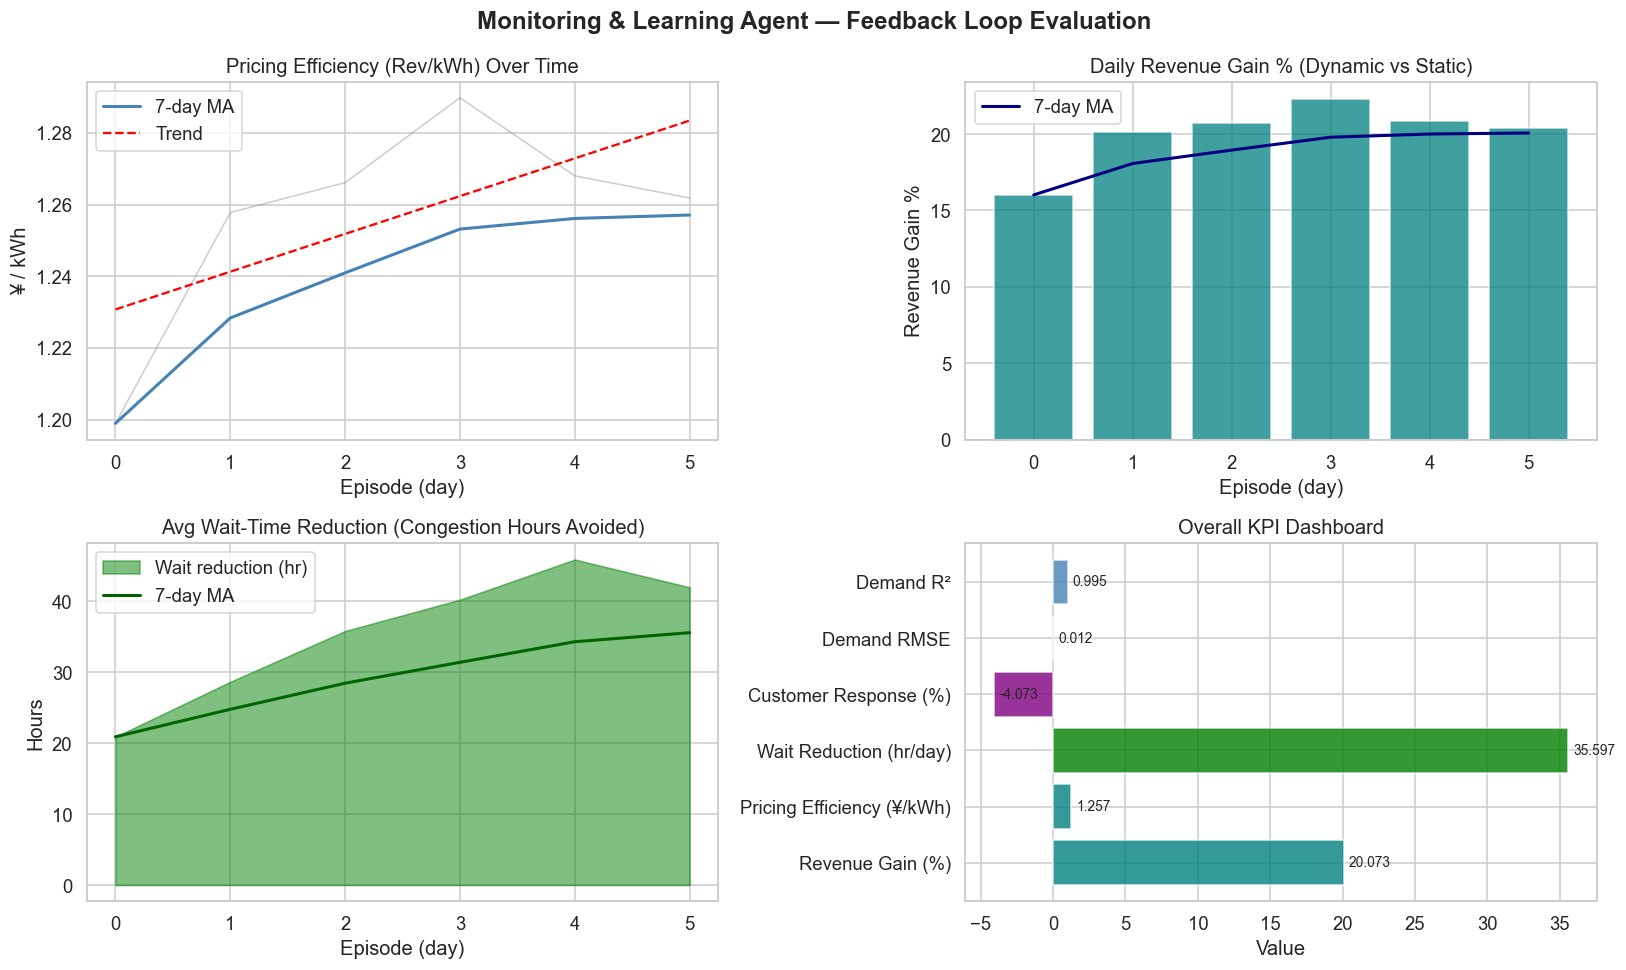

In [59]:
# ---------- Feedback loop: does pricing efficiency improve over episodes? ----------
episodes['episode_num'] = range(len(episodes))

# Rolling 7-day mean
episodes['eff_roll7']    = episodes['pricing_efficiency'].rolling(7, min_periods=1).mean()
episodes['revgain_roll7']= episodes['revenue_gain_pct'].rolling(7, min_periods=1).mean()

# Fit trend line
from numpy.polynomial import polynomial as P
coef = np.polyfit(episodes['episode_num'], episodes['pricing_efficiency'], 1)
trend = np.poly1d(coef)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Monitoring & Learning Agent — Feedback Loop Evaluation', fontweight='bold')

# 1. Pricing efficiency over episodes
ax = axes[0, 0]
ax.plot(episodes['episode_num'], episodes['pricing_efficiency'], color='gray', alpha=0.4, linewidth=1)
ax.plot(episodes['episode_num'], episodes['eff_roll7'], color='steelblue', linewidth=2, label='7-day MA')
ax.plot(episodes['episode_num'], trend(episodes['episode_num']), 'r--', linewidth=1.5, label='Trend')
ax.set_title('Pricing Efficiency (Rev/kWh) Over Time')
ax.set_xlabel('Episode (day)')
ax.set_ylabel('¥ / kWh')
ax.legend()

# 2. Revenue gain % over episodes
ax = axes[0, 1]
ax.bar(episodes['episode_num'], episodes['revenue_gain_pct'],
       color=np.where(episodes['revenue_gain_pct'] > 0, 'teal', 'coral'), alpha=0.75)
ax.plot(episodes['episode_num'], episodes['revgain_roll7'], color='navy', linewidth=2, label='7-day MA')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Daily Revenue Gain % (Dynamic vs Static)')
ax.set_xlabel('Episode (day)')
ax.set_ylabel('Revenue Gain %')
ax.legend()

# 3. Wait-time reduction over episodes
ax = axes[1, 0]
ax.fill_between(episodes['episode_num'], episodes['wait_time_reduction_hr'],
                alpha=0.5, color='green', label='Wait reduction (hr)')
ax.plot(episodes['episode_num'],
        episodes['wait_time_reduction_hr'].rolling(7,min_periods=1).mean(),
        color='darkgreen', linewidth=2, label='7-day MA')
ax.set_title('Avg Wait-Time Reduction (Congestion Hours Avoided)')
ax.set_xlabel('Episode (day)')
ax.set_ylabel('Hours')
ax.legend()

# 4. Comprehensive KPI dashboard
ax = axes[1, 1]
kpis = {
    'Revenue Gain (%)':       episodes['revenue_gain_pct'].mean(),
    'Pricing Efficiency (¥/kWh)': episodes['pricing_efficiency'].mean(),
    'Wait Reduction (hr/day)':episodes['wait_time_reduction_hr'].mean(),
    'Customer Response (%)':  episodes['customer_response_rate_pct'].mean(),
    'Demand RMSE':            rmse_gb,
    'Demand R²':              r2_gb,
}
y_pos = range(len(kpis))
colors_kpi = ['teal','teal','green','purple','steelblue','steelblue']
bars = ax.barh(list(kpis.keys()), list(kpis.values()), color=colors_kpi, alpha=0.8)
for bar, val in zip(bars, kpis.values()):
    ax.text(bar.get_width() + 0.01 * max(kpis.values()),
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Overall KPI Dashboard')
ax.set_xlabel('Value')

plt.tight_layout()
plt.savefig('monitoring_agent_feedback.png')
plt.show()

---
## 7. Evaluation Summary

In [60]:
# ---------- Final evaluation report ----------
summary = pd.DataFrame({
    'Agent': [
        'Demand Prediction Agent', 'Demand Prediction Agent', 'Demand Prediction Agent',
        'Tariff Pricing Agent', 'Tariff Pricing Agent', 'Tariff Pricing Agent',
        'Monitoring & Learning Agent', 'Monitoring & Learning Agent', 'Monitoring & Learning Agent'
    ],
    'Metric': [
        'RMSE (utilization_rate)', 'MAE (utilization_rate)', 'R²',
        'Revenue Gain (%)', 'Charger Utilization After', 'Off-Peak Uplift (%)',
        'Avg Wait-Time Reduction (hr/day)', 'Avg Customer Response Rate (%)', 'Avg Pricing Efficiency (¥/kWh)'
    ],
    'Value': [
        round(rmse_gb, 4), round(mae_gb, 4), round(r2_gb, 4),
        round(revenue_gain_pct, 2), round(util_after, 3), round(offpeak_uplift_pct, 1),
        round(episodes['wait_time_reduction_hr'].mean(), 3),
        round(episodes['customer_response_rate_pct'].mean(), 3),
        round(episodes['pricing_efficiency'].mean(), 4)
    ]
})

summary.to_csv('evaluation_summary.csv', index=False)
print('=== FINAL EVALUATION SUMMARY ===')
print(summary.to_string(index=False))

=== FINAL EVALUATION SUMMARY ===
                      Agent                           Metric   Value
    Demand Prediction Agent          RMSE (utilization_rate)  0.0123
    Demand Prediction Agent           MAE (utilization_rate)  0.0048
    Demand Prediction Agent                               R²  0.9951
       Tariff Pricing Agent                 Revenue Gain (%) 20.3600
       Tariff Pricing Agent        Charger Utilization After  0.2920
       Tariff Pricing Agent              Off-Peak Uplift (%)  7.5000
Monitoring & Learning Agent Avg Wait-Time Reduction (hr/day) 35.5970
Monitoring & Learning Agent   Avg Customer Response Rate (%) -4.0730
Monitoring & Learning Agent   Avg Pricing Efficiency (¥/kWh)  1.2571


In [ ]:
# ---------- Limitations & Assumptions ----------
print("""
=== TRANSPARENCY: ASSUMPTIONS & LIMITATIONS ===

1. TARIFF BASELINE
   - For ACN (US dataset), a ₹15/kWh INR reference is used as the fixed baseline
     per the project brief; actual USD pricing at Caltech is different.
   - For ST-EVCDP (Shenzhen), the observed median price (~1 ¥/kWh) is the baseline.

2. DEMAND ELASTICITY
   - Own-price elasticity assumed at -0.30 (mid-range literature estimate).
   - No cross-price or income elasticities modelled. Causal interpretation avoided.

3. MISSING VALUES
   - ACN kWhRequested filled with station-median (not per-user).
   - ST-EVCDP panel nulls filled with station-level temporal median.

4. WAIT-TIME REDUCTION
   - Computed as a proxy (congestion-slot-hours avoided), not from queue records.

5. MODEL SCOPE
   - Demand model trained on urban ST-EVCDP due to availability of occupancy
     and volume time series. ACN used for session-level EDA.
   - No spatial graph neural network used; adjacency matrix provided for
     network EDA and could support GNN extensions.

6. CAUSAL CLAIMS
   - All results are associational. Dynamic pricing effects are simulated
     using elasticity assumptions, not from a natural experiment.
""")

In [ ]:
print('Output files generated:')
import os
outputs = [
    'acn_processed.csv', 'urban_processed.csv', 'acn_hourly.csv',
    'network_metrics.csv', 'demand_prediction_metrics.csv',
    'tariff_agent_metrics.csv', 'monitoring_agent_episodes.csv',
    'evaluation_summary.csv',
    'eda_acn.png', 'eda_urban.png', 'network_analysis.png',
    'demand_agent_diagnostics.png', 'tariff_agent_outcomes.png',
    'monitoring_agent_feedback.png'
]
for f in outputs:
    exists = '✓' if os.path.exists(f) else '✗'
    print(f'  {exists}  {f}')